# 6주차 실습 · 분류와 배치 — 다섯 줄, 여섯 번
**피지컬AI응용 (MR347) · 2026-2 · 인하공업전문대학 컴퓨터시스템공학과**

| 부품 | 무엇 | 코드 |
|---|---|---|
| ① 분류로 바꾸기 | 출력 = 클래스 수 · `CrossEntropyLoss` · **y 는 (n,) long** · `argmax` | 두 줄 + y 한 줄 |
| ② 배치와 평가 | `DataLoader` 로 묶어 넣기 · `evaluate()` 함수 · 학습 곡선 | for 한 겹 + 함수 하나 |
| ③ 모델 클래스 | `class Net(nn.Module)` · `torch.save` | 7주차 CNN 이 이 형식 |

| 예제 | 데이터 | 새로 붙는 것 | 형식 |
|---|---|---|---|
| 1 | 배송 소비전력 (과제 2) · 회귀 | 없음 — 5주차 재현 | **백지** |
| 2 | 로봇 고장 (3주차) · 이진분류 | ① | **백지** |
| 3 | 배송 지연 (과제 2) · 불균형 이진분류 | softmax · 재현율 | 빈칸 |
| 4 | 손글씨 digits 8×8 · 10클래스 | ② | 빈칸 |
| 5 | **MNIST** 28×28 · 60,000장 | ③ | 보고 치기 |
| 6 | 운행모드 (과제 2) · 3클래스 | 혼자서 | 과제 |

**규칙** — 준비 셀을 먼저 실행. 예제 1·2 는 아무것도 보지 말고 씁니다. 예상 출력과 같으면 통과. AI 사용 금지.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             confusion_matrix, recall_score, precision_score)

print("torch", torch.__version__)
print("준비 완료")


torch 2.11.0+cpu
준비 완료


In [ ]:
# ===== 데이터 준비 (그대로 실행하세요) =====
# [1] 배송 로봇 run — 과제 2 와 같은 데이터
rng = np.random.default_rng(2026); n = 300
load = rng.uniform(0, 30, n); slope = rng.uniform(0, 10, n); temp = rng.uniform(-5, 35, n); speed = rng.uniform(0.5, 2.0, n)
power = 40 + 3*load + 6*slope + 25*speed + rng.normal(0, 8, n)
rng2 = np.random.default_rng(99)
z = 0.10*load + 0.25*slope - 1.0*speed + 0.03*(temp - 15) - 2.9 + rng2.normal(0, 1.6, n)
run = pd.DataFrame({"적재중량": load.round(1), "경사": slope.round(1), "기온": temp.round(1),
                    "속도": speed.round(2), "소비전력": power.round(1), "지연": (z > 0).astype(int)})
X_run = run[["적재중량", "경사", "기온", "속도"]].values
y_power = run["소비전력"].values
y_delay = run["지연"].values

# [2] 로봇 고장 — 3주차 데이터
rng4 = np.random.default_rng(22); n2 = 200
temp2 = rng4.uniform(15, 45, n2); vib2 = rng4.uniform(0, 5, n2)
X_fault = np.c_[temp2.round(1), vib2.round(2)]
y_fault = (0.25*temp2 + 1.2*vib2 - 10 + rng4.normal(0, 1, n2) > 0).astype(int)

# [3] 운행 로그 log — 과제 2 와 같은 데이터 (예제 6)
rng3 = np.random.default_rng(7); m = 240
mode = rng3.integers(0, 3, m)
sp = np.where(mode == 0, rng3.normal(0.7, 0.12, m), np.where(mode == 1, rng3.normal(1.6, 0.15, m), rng3.normal(1.1, 0.15, m)))
sl = np.where(mode == 0, rng3.normal(0.5, 0.3, m),  np.where(mode == 1, rng3.normal(1.0, 0.5, m),  rng3.normal(7.0, 1.2, m)))
vb = np.where(mode == 0, rng3.normal(0.8, 0.2, m),  np.where(mode == 1, rng3.normal(2.6, 0.4, m),  rng3.normal(3.2, 0.5, m)))
log = pd.DataFrame({"속도": sp.clip(0.2).round(2), "경사": sl.clip(0).round(1), "진동": vb.clip(0).round(2),
                    "주행거리": rng3.uniform(200, 2000, m).round(0), "운행모드": mode})
X_log = log[["속도", "경사", "진동", "주행거리"]].values
y_mode = log["운행모드"].values

print("run", X_run.shape, "| 지연 비율", y_delay.mean().round(2))
print("fault", X_fault.shape, "| log", X_log.shape, "| 모드 분포", np.bincount(y_mode))


run (300, 4) | 지연 비율 0.31
fault (200, 2) | log (240, 4) | 모드 분포 [67 90 83]


**실행 결과** (torch 버전 줄은 달라도 됩니다)
```
run (300, 4) | 지연 비율 0.31
fault (200, 2) | log (240, 4) | 모드 분포 [67 90 83]
```

---
### 예제 1 · 워밍업 — 배송 소비전력 회귀 (백지)

5주차 암기 내용 그대로. `X_run` → `y_power`. 외운대로 한번 시도해봅시다.

1. 8:2 로 나누기(random_state=42) → X, y 둘 다 표준화 → float32 텐서 (y 는 (n,1))
2. `nn.Sequential(nn.Linear(4, 1))` · `MSELoss` · `SGD(lr=0.1)` → 다섯 줄 200 epoch
3. 가중치를 원래 단위로 되돌려 계수 출력, 시험 R² 출력

과제 2 A1 의 sklearn 계수 `[3.04, 6.38, -0.05, 24.39]`, R² 0.9467 과 같아야 합니다.

> 💡 **힌트** — 이전 실습과 완전히 같습니다. 특성이 2개 → 4개로 바뀐 것뿐. 계수 복원은 `w * sy.scale_ / sx.scale_`.

**예상 출력**
```
계수: [ 3.04  6.38 -0.05 24.39]
R2: 0.9467
```


In [ ]:
# 여기에 코드를 쓰세요 (백지)
X_train, X_test, y_train, y_test = train_test_split(X_run, y_power, test_size=0.2, random_state=42)
sx = StandardScaler().fit(X_train)
sy = StandardScaler().fit(y_train.reshape(-1, 1))
X_t = torch.tensor(sx.transform(X_train), dtype=torch.float32)
y_t = torch.tensor(sy.transform(y_train.reshape(-1, 1)), dtype=torch.float32)

torch.manual_seed(0)
model = nn.Sequential(nn.Linear(4, 1))
loss_fn = nn.MSELoss()
opt = optim.SGD(model.parameters(), lr=0.1)
for epoch in range(200):
    opt.zero_grad(); pred = model(X_t); loss = loss_fn(pred, y_t); loss.backward(); opt.step()
w=model[0].weight.detach().numpy().reshape(-1)
with torch.no_grad():
    pred_test = sy.inverse_transform(model(torch.tensor(sx.transform(X_test), dtype=torch.float32)).detach().numpy())
print("계수:", (w*sy.scale_/sx.scale_))
print("R2:", round(r2_score(y_test, pred_test), 4))

계수: [ 3.04044651  6.38287465 -0.05393475 24.39410703]
R2: 0.9467


---
### 예제 2 · 분류 두 줄 - 로봇 고장

`X_fault` → `y_fault`. 회귀에서 **바뀌는 곳만** 바꿉니다.

- 출력 2개: `nn.Linear(2, 2)` · `nn.CrossEntropyLoss()`
- y 는 `dtype=torch.long`, **reshape 하지 않음** — 모양 (160,)
- X 만 표준화 (y 는 클래스 번호라 안 함) · `Adam(lr=0.01)` · 200 epoch
- 예측 = `model(X).argmax(dim=1)` → 정확도와 혼동행렬

이전 로지스틱 회귀의 0.875, `[[17, 5], [0, 18]]` 과 같아야 합니다.

> 💡 **힌트** — y_t = torch.tensor(y_train, dtype=torch.long) / 예측은 `with torch.no_grad(): pred = model(X_e).argmax(dim=1).numpy()`.

**예상 출력**
```
y_t: torch.Size([160]) torch.int64
정확도: 0.875
[[17  5]
 [ 0 18]]
```


In [ ]:
# 여기에 코드를 쓰세요 (백지)
# 여기에 코드를 쓰세요 (백지)
X_train, X_test, y_train, y_test = train_test_split(X_fault, y_fault, test_size=0.2, random_state=42)
sx = StandardScaler().fit(X_train)
sy = StandardScaler().fit(y_train.reshape(-1, 1))
X_t = torch.tensor(sx.transform(X_train), dtype=torch.float32)
X_e = torch.tensor(sx.transform(X_test), dtype=torch.float32)
y_t = torch.tensor(y_train,dtype=torch.long)

print("y_t: ", y_t.shape, y_t.dtype)

torch.manual_seed(0)
model = nn.Sequential(nn.Linear(2,2))
loss_fn = nn.CrossEntropyLoss()
opt = optim.Adam(model.parameters(), lr=0.01)
for epoch in range(200):
    opt.zero_grad(); pred = model(X_t); loss = loss_fn(pred, y_t); loss.backward(); opt.step()
with torch.no_grad():
    pred = model(X_e).argmax(dim=1).numpy()
print("정확도", round(accuracy_score(y_test, pred)))
print(confusion_matrix(y_test, pred))

y_t:  torch.Size([160]) torch.int64
정확도 1
[[17  5]
 [ 0 18]]


---
### 예제 3 · 불균형 분류 - 배송 지연 (빈칸)

`X_run` → `y_delay` (지연 31%). 나누기에 **stratify=y_delay** 를 넣습니다.

1. 선형 `nn.Linear(4, 2)` 로 300 epoch → 정확도·**재현율**·혼동행렬
2. 같은 코드에서 모델만 `nn.Linear(4,16), nn.ReLU(), nn.Linear(16,2)` 로 → 다시 출력
3. 1번 모델의 출력에 `torch.softmax(out, dim=1)[:, 1]` 로 지연 확률을 구하고, **0.3 이상이면 지연**으로 바꿔 재현율·정밀도·정확도 출력

과제 2 B1 의 로지스틱 0.767, `[[37, 4], [10, 9]]` 과 비교

> 💡 **힌트** — 빈칸은 모델 두 줄과 softmax 한 줄
`prob = torch.softmax(out, dim=1)[:, 1].numpy()` → `p3 = (prob >= 0.3).astype(int)`.

**예상 출력**
```
정확도 0.767  재현율 0.474
[[37  4]
 [10  9]]
정확도 0.767  재현율 0.368
[[39  2]
 [12  7]]
기준 0.3 → 재현율 0.895  정밀도 0.739  정확도 0.867
```


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_run, y_delay, test_size=0.2, random_state=42, stratify=y_delay)
sx = StandardScaler().fit(X_train)
X_t = torch.tensor(sx.transform(X_train), dtype=torch.float32)
X_e = torch.tensor(sx.transform(X_test),  dtype=torch.float32)
y_t = torch.tensor(y_train, dtype=torch.long)

def fit_and_report(model, epochs=300):
    loss_fn = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=0.01)
    for epoch in range(epochs):
        opt.zero_grad(); pred = model(X_t); loss = loss_fn(pred, y_t); loss.backward(); opt.step()
    with torch.no_grad():   #평가
        out = model(X_e)
    pred = out.argmax(dim=1).numpy()
    print("정확도", round(accuracy_score(y_test, pred), 3), " 재현율", round(recall_score(y_test, pred), 3))
    print(confusion_matrix(y_test, pred))
    return out

torch.manual_seed(0)
out_lin = fit_and_report(nn.Sequential(nn.Linear(4,2)))      # 1) 선형 4 → 2

torch.manual_seed(0)
out_mlp = fit_and_report(nn.Sequential(nn.Linear(4,16)))      # 2) MLP 4 → 16 → 2

prob = torch.softmax(out_lin, dim=1)[:,1].numpy()                          # 3) 선형 모델의 지연 확률 (softmax 두 번째 열)
p3 = (prob >= 0.3).astype(int)
print("기준 0.3 → 재현율", round(recall_score(y_test, p3), 3), " 정밀도", round(precision_score(y_test, p3), 3), " 정확도", round(accuracy_score(y_test, p3), 3))


정확도 0.767  재현율 0.474
[[37  4]
 [10  9]]
정확도 0.783  재현율 0.526
[[37  4]
 [ 9 10]]
기준 0.3 → 재현율 0.895  정밀도 0.739  정확도 0.867


---
### 예제 4 · 배치와 평가 함수 - 손글씨 digits 10클래스

`sklearn.datasets.load_digits` — 8×8 손글씨 1,797장, 특성 64개, 클래스 10개. 데이터가 커지면 한 번에 넣지 않고 **배치**로 나눠 넣기

1. train/val/test = 1149/288/360 (주어진 코드) → `TensorDataset` + `DataLoader(batch_size=64, shuffle=True)`
2. **다섯 줄이 `for xb, yb in loader:` 안으로** 들어감. epoch 20
3. 주어진 `evaluate()` 로 epoch 마다 검증 정확도를 기록해 출력하고, 마지막에 시험 정확도

빈칸은 DataLoader 한 줄과 안쪽 for 의 그 외운거 들어가기.

> 💡 **힌트** — `loader = DataLoader(TensorDataset(X_t, y_t), batch_size=64, shuffle=True)` / 안쪽: `for xb, yb in loader:` 아래에 다섯 줄 — X_t 대신 xb, y_t 대신 yb.

**예상 결과** — 숫자 출력 + 검증 정확도 곡선(epoch 1~20)
```
train/val/test: 1149 288 360
배치 수: 18
epoch  1  val acc 0.878
epoch  2  val acc 0.910
epoch  3  val acc 0.944
epoch  5  val acc 0.948
epoch 10  val acc 0.972
epoch 20  val acc 0.976
test acc: 0.9694
```


train/val/test: 1149 288 360
배치 수: 18
epoch  1  val acc 0.878
epoch  2  val acc 0.910
epoch  3  val acc 0.944
epoch  5  val acc 0.948
epoch 10  val acc 0.972
epoch 20  val acc 0.976
test acc: 0.9694


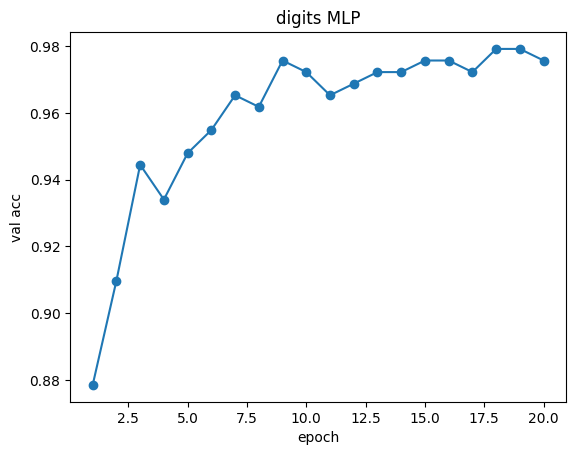

In [ ]:
from sklearn.datasets import load_digits
d = load_digits()
dataset = TensorDataset(X_t, y_t)

#loader = DataLoader(dataset, batch_size=64, shuffle=True)
#len(loader)
#xb, yb = next(iter(loader)); xb.shape, yb.shape

Xd, yd = d.data / 16.0, d.target                      # 0~16 → 0~1 로 (이미지는 이렇게 간단히)
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.2, random_state=42, stratify=yd)
Xd_tr, Xd_va, yd_tr, yd_va = train_test_split(Xd_tr, yd_tr, test_size=0.2, random_state=42, stratify=yd_tr)
T = lambda a, dt: torch.tensor(a, dtype=dt)
X_t, y_t = T(Xd_tr, torch.float32), T(yd_tr, torch.long)
X_v, y_v = T(Xd_va, torch.float32), T(yd_va, torch.long)
X_e, y_e = T(Xd_te, torch.float32), T(yd_te, torch.long)
print("train/val/test:", len(X_t), len(X_v), len(X_e))

def evaluate(model, X, y):                             # 평가 함수 — 기록 끄고 정확도만
    model.eval()
    with torch.no_grad():
        acc = (model(X).argmax(dim=1) == y).float().mean().item()
    model.train()
    return acc

loader = DataLoader(TensorDataset(X_t, y_t), batch_size=64, shuffle=True)
                                          # ① DataLoader
print("배치 수:", len(loader))

torch.manual_seed(0)
model   = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 10))
loss_fn = nn.CrossEntropyLoss()
opt     = optim.Adam(model.parameters(), lr=0.01)
history = []
for epoch in range(20):
    for xb, yb in loader:
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()                                            # ② 다섯 줄
    history.append(evaluate(model, X_v, y_v))
    if (epoch + 1) in (1, 2, 3, 5, 10, 20): print(f"epoch {epoch+1:2d}  val acc {history[-1]:.3f}")
print("test acc:", round(evaluate(model, X_e, y_e), 4))

plt.plot(range(1, 21), history, marker="o"); plt.xlabel("epoch"); plt.ylabel("val acc"); plt.title("digits MLP"); plt.show()


---
### 예제 5 · 진짜 데이터 — MNIST 60,000장, 모델 클래스, 저장 (화면 참고하세요)

`torchvision` 으로 MNIST 를 받아 **`class Net(nn.Module)`** 로 모델을 쓰고, 5 epoch 학습 → 저장 → 새 모델에 불러와 같은 예측인지 확인합니다.
코드를 **보고 그대로 쳐봐도 됩니다.** 바뀐 곳은 ① 모델이 클래스 ② 입력이 (1, 28, 28) 이라 `nn.Flatten()` ③ 평가도 배치로.

Colab 에서 데이터 다운로드에 10~20초. CPU 로 epoch 당 약 4초.


**예상 결과** — epoch 별 loss·검증 정확도 + 시험 정확도 + 틀린 손글씨 6장
```
배치: torch.Size([64, 1, 28, 28]) torch.Size([64]) | 배치 수: 782
파라미터: 101770
epoch 1  마지막 배치 loss 0.073  val acc 0.9352
epoch 2  마지막 배치 loss 0.301  val acc 0.9531
epoch 3  마지막 배치 loss 0.029  val acc 0.9601
epoch 4  마지막 배치 loss 0.021  val acc 0.9645
epoch 5  마지막 배치 loss 0.003  val acc 0.9695
test acc: 0.9749
불러온 모델 test acc: 0.9749
```


In [ ]:
# 아래 코드를 보고 그대로 치세요 (교수용 노트북 / 슬라이드 참고)




train/val/test: 1149 288 360


---
### 예제 6 · 과제 - 운행모드 3클래스 (혼자서)

`X_log` → `y_mode` (0 실내저속 / 1 실외평지 / 2 실외경사). 예제 2·3 과 같은 방식으로 **혼자** 시도해보세요.

- stratify 로 8:2, X 표준화, `nn.Linear(4,16), nn.ReLU(), nn.Linear(16,3)`, Adam 0.01, 300 epoch
- 시험 정확도와 혼동행렬 출력
- **표준화를 빼고** 한 번 더 돌려 정확도 비교 → 결론 한 문장


> 💡 **힌트** — 출력이 3개면 `nn.Linear(16, 3)`, y 는 0·1·2 그대로 long. 나머지는 예제 3 과 같습니다.

**예상 출력**
```
표준화 O 정확도: 1.0
[[13  0  0]
 [ 0 18  0]
 [ 0  0 17]]
표준화 X 정확도: 0.917
[[12  1  0]
 [ 3 15  0]
 [ 0  0 17]]
```


In [ ]:
# 여기에 코드를 쓰세요 (과제)


---
## 6주차 암기 내용, 이전내용에 추가
```python
loss_fn = nn.CrossEntropyLoss()                 # 분류 손실 (출력 = 클래스 수)
y_t = torch.tensor(y_train, dtype=torch.long)   # y 는 (n,) long — reshape 안 함
for xb, yb in loader:                           # 배치 — 다섯 줄이 이 안으로
pred = model(X).argmax(dim=1)                   # 예측 읽기
```

